In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Collecte & Nettoyage

In [8]:
start = "2005-01-01"
end   = "2024-12-31"

tickers = ["^GSPC", "GLD"]  # <- OR via ETF GLD

data = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False,
    progress=True
)

print("\nStructure brute :")
print(data.head())
print("\nColonnes :")
print(data.columns)

prices = data["Adj Close"]
prices.columns = ["SP500", "GLD"]

prices = prices.dropna()

print("\nPériode valide commune SP500 / GLD :", prices.index.min(), "→", prices.index.max())
print("\nAperçu des prix nettoyés :")
print(prices.head())

returns = np.log(prices / prices.shift(1)).dropna()

print("\nAperçu des rendements :")
print(returns.head())

[*********************100%***********************]  2 of 2 completed


Structure brute :
Price       Adj Close                   Close                    High  \
Ticker            GLD        ^GSPC        GLD        ^GSPC        GLD   
Date                                                                    
2005-01-03  43.020000  1202.079956  43.020000  1202.079956  43.169998   
2005-01-04  42.740002  1188.050049  42.740002  1188.050049  42.910000   
2005-01-05  42.669998  1183.739990  42.669998  1183.739990  42.880001   
2005-01-06  42.150002  1187.890015  42.150002  1187.890015  42.560001   
2005-01-07  41.840000  1186.189941  41.840000  1186.189941  42.389999   

Price                          Low                    Open               \
Ticker            ^GSPC        GLD        ^GSPC        GLD        ^GSPC   
Date                                                                      
2005-01-03  1217.800049  42.740002  1200.319946  42.980000  1211.920044   
2005-01-04  1205.839966  42.459999  1185.390015  42.799999  1202.079956   
2005-01-05  1192.7299

# 2.Évolution des actifs

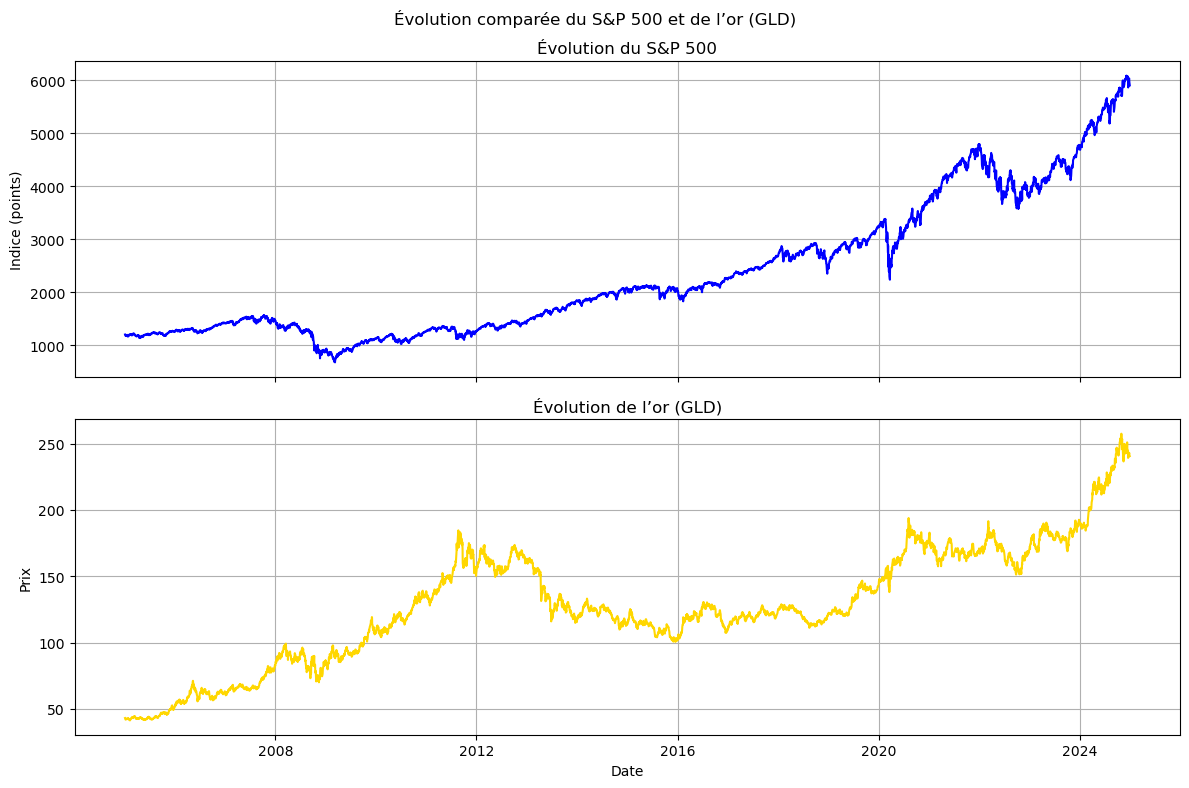

In [9]:
sp500 = data["Adj Close"]["^GSPC"]
gold  = data["Adj Close"]["GLD"]

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# S&P 500
axes[0].plot(sp500, color="blue")
axes[0].set_title("Évolution du S&P 500")
axes[0].set_ylabel("Indice (points)")
axes[0].grid(True)

# Or (GLD)
axes[1].plot(gold, color="gold")
axes[1].set_title("Évolution de l’or (GLD)")
axes[1].set_ylabel("Prix")
axes[1].set_xlabel("Date")
axes[1].grid(True)

plt.suptitle("Évolution comparée du S&P 500 et de l’or (GLD)")
plt.tight_layout()
plt.show()

# 3.Corrélation


Matrice de corrélation SP500 / GLD :
           SP500       GLD
SP500  1.000000  0.057763
GLD    0.057763  1.000000


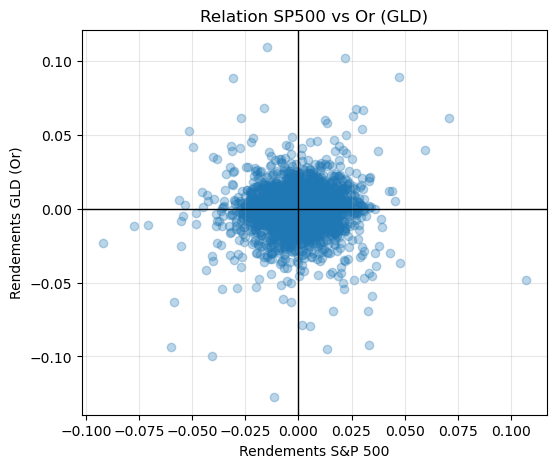

In [10]:
corr = returns.corr()
print("\nMatrice de corrélation SP500 / GLD :\n", corr)

plt.figure(figsize=(6,5))
plt.scatter(returns["SP500"], returns["GLD"], alpha=0.3)
plt.axhline(0, color="black", lw=1)
plt.axvline(0, color="black", lw=1)
plt.xlabel("Rendements S&P 500")
plt.ylabel("Rendements GLD (Or)")
plt.title("Relation SP500 vs Or (GLD)")
plt.grid(alpha=0.3)
plt.show()

# 4. Corrélation glissante (rolling correlation) — SP500 vs Or (GLD)

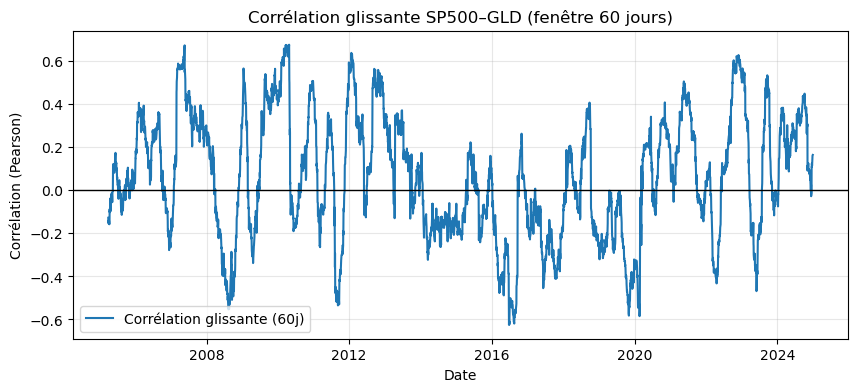

In [11]:
window_corr = 60  # ex: 60 jours (~3 mois). Tu peux tester 20 / 120 / 252.
rolling_corr = returns["SP500"].rolling(window_corr).corr(returns["GLD"])

plt.figure(figsize=(10,4))
plt.plot(rolling_corr.index, rolling_corr, label=f"Corrélation glissante ({window_corr}j)")
plt.axhline(0, color="black", lw=1)
plt.title(f"Corrélation glissante SP500–GLD (fenêtre {window_corr} jours)")
plt.ylabel("Corrélation (Pearson)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 5.Corrélation conditionnelle à la volatilité (vol réalisée)


Seuils vol annualisée S&P500 :
q33 = 0.164, q66 = 0.222

Corrélation conditionnelle SP500–GLD par régime de volatilité :
regime_vol
Faible vol     0.033086
Forte vol      0.075296
Vol moyenne    0.062300
Name: (SP500, GLD), dtype: float64


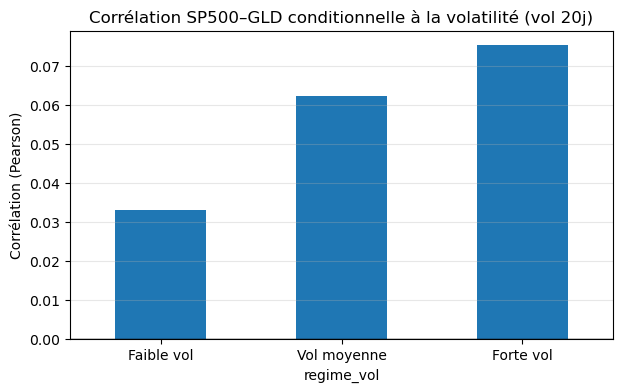

In [12]:
# 1) Volatilité glissante du S&P500 (ex: 20 jours)
window_vol = 20
vol_sp500 = returns["SP500"].rolling(window_vol).std() * np.sqrt(252)  # annualisée
df = returns.copy()
df["vol_sp500"] = vol_sp500
df = df.dropna()

# 2) Définir des régimes de volatilité via quantiles
q_low, q_high = df["vol_sp500"].quantile([0.65, 0.85])

def vol_regime(v):
    if v <= q_low:
        return "Faible vol"
    elif v <= q_high:
        return "Vol moyenne"
    else:
        return "Forte vol"

df["regime_vol"] = df["vol_sp500"].apply(vol_regime)

# 3) Corrélation SP500–GLD par régime de volatilité
corr_by_regime = df.groupby("regime_vol")[["SP500", "GLD"]].corr().unstack().iloc[:, 1]

print("\nSeuils vol annualisée S&P500 :")
print(f"q33 = {q_low:.3f}, q66 = {q_high:.3f}")
print("\nCorrélation conditionnelle SP500–GLD par régime de volatilité :")
print(corr_by_regime)

# 4) Visualisation (bar plot)
plt.figure(figsize=(7,4))
corr_by_regime.reindex(["Faible vol","Vol moyenne","Forte vol"]).plot(kind="bar")
plt.axhline(0, color="black", lw=1)
plt.title(f"Corrélation SP500–GLD conditionnelle à la volatilité (vol {window_vol}j)")
plt.ylabel("Corrélation (Pearson)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 6. Corrélation en période de drawdown (niveau)


Drawdown threshold : -8%
Nb jours en drawdown : 3307 / 5031 (65.7%)
Corrélation SP500–GLD en drawdown : 0.064
Corrélation SP500–GLD hors drawdown : 0.042


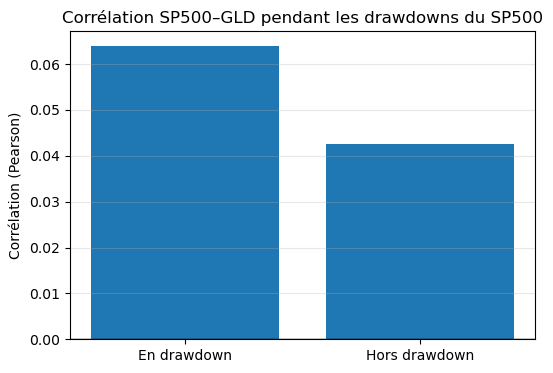

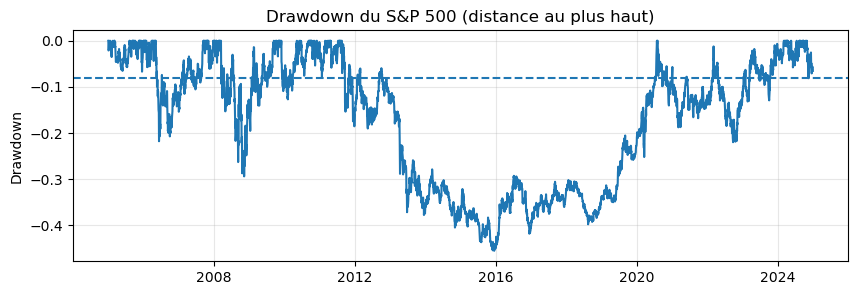


Seuil drawdown (pire 20%) : -33.5%
Corrélation SP500–GLD pire 20% drawdowns : -0.158
Corrélation SP500–GLD reste du temps : 0.084


In [13]:
# 1) Reconstruire un indice de prix SP500 à partir des log-returns (base 100)
sp_index = np.exp(returns["SP500"].cumsum()) * 100

# 2) Calcul du drawdown : distance au plus haut historique
running_max = sp_index.cummax()
drawdown = sp_index / running_max - 1  # ex: -0.10 = -10%

dd_df = returns.copy()
dd_df["sp_index"] = sp_index
dd_df["drawdown"] = drawdown
dd_df = dd_df.dropna()

# 3) Choix d'un seuil de drawdown "significatif"
dd_threshold = -0.08# -10% (tu peux tester -0.15, -0.20)
dd_df["in_drawdown"] = dd_df["drawdown"] <= dd_threshold

# 4) Corrélation conditionnelle
corr_dd = dd_df.loc[dd_df["in_drawdown"], ["SP500", "GLD"]].corr().iloc[0, 1]
corr_no_dd = dd_df.loc[~dd_df["in_drawdown"], ["SP500", "GLD"]].corr().iloc[0, 1]

n_dd = dd_df["in_drawdown"].sum()
n_total = len(dd_df)

print(f"\nDrawdown threshold : {dd_threshold:.0%}")
print(f"Nb jours en drawdown : {n_dd} / {n_total} ({n_dd/n_total:.1%})")
print(f"Corrélation SP500–GLD en drawdown : {corr_dd:.3f}")
print(f"Corrélation SP500–GLD hors drawdown : {corr_no_dd:.3f}")

# 5) Visualisation simple : corrélations comparées
plt.figure(figsize=(6,4))
plt.bar(["En drawdown", "Hors drawdown"], [corr_dd, corr_no_dd])
plt.axhline(0, color="black", lw=1)
plt.ylabel("Corrélation (Pearson)")
plt.title("Corrélation SP500–GLD pendant les drawdowns du SP500")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Visualiser le drawdown dans le temps
plt.figure(figsize=(10,3))
plt.plot(dd_df.index, dd_df["drawdown"])
plt.axhline(dd_threshold, linestyle="--")
plt.title("Drawdown du S&P 500 (distance au plus haut)")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)
plt.show()

# Corrélation en drawdown : approche par quantile
worst_pct = 0.20
dd_cut = dd_df["drawdown"].quantile(worst_pct)  # ex: 20% pires drawdowns

corr_worst_dd = dd_df.loc[dd_df["drawdown"] <= dd_cut, ["SP500", "GLD"]].corr().iloc[0, 1]
corr_rest = dd_df.loc[dd_df["drawdown"] > dd_cut, ["SP500", "GLD"]].corr().iloc[0, 1]

print(f"\nSeuil drawdown (pire {int(worst_pct*100)}%) : {dd_cut:.1%}")
print(f"Corrélation SP500–GLD pire {int(worst_pct*100)}% drawdowns : {corr_worst_dd:.3f}")
print(f"Corrélation SP500–GLD reste du temps : {corr_rest:.3f}")